<a href="https://colab.research.google.com/github/williamtheodoruswijaya/semantix/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture

!pip install torch torchvision torchaudio
!pip install segmentation-models-pytorch timm
!pip install albumentations opencv-python pillow pandas scikit-learn tqdm

## Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import cv2

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import os
import zipfile
import random
import json
from pathlib import Path

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

## Import Dataset

- Unzip dataset

In [6]:
os.makedirs("/content/flopwd_data", exist_ok=True)

with zipfile.ZipFile("/content/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025).zip", "r") as zip_ref:
  zip_ref.extractall("/content/flopwd_data")

- Get Images

In [11]:
raw_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images").glob("*")))
mask_images = sorted(list(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks").glob("*")))
labels_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Image_labels_Binary Classification Task.csv")
reg_csv = Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Mask_foreground_percentages_Regression Task.csv")

In [15]:
labels_df = pd.read_csv(labels_csv)
reg_df = pd.read_csv(reg_csv)

In [16]:
labels_df.head()

,image name,Presence of plastic waste?
0,img1.jpg,yes
1,img2.jpg,yes
2,img3.jpg,yes
3,img4.jpg,yes
4,img5.jpg,yes


In [17]:
reg_df.head()

,image name,plastic waste accumulation (in percentage)
0,img1.jpg,0.08
1,img2.jpg,0.03
2,img3.jpg,0.38
3,img4.jpg,0.20
4,img5.jpg,0.18


### Transform Dataset

In [20]:
labels_df = labels_df.rename(columns={
    "image name": "image_name",
    "Presence of plastic waste?": "presence"
})

reg_df = reg_df.rename(columns={
    "image name": "image_name",
    "plastic waste accumulation (in percentage)": "fg_pct"
})

df = labels_df.merge(reg_df, on="image_name", how="inner")

df["image_path"] = df["image_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Raw_Images") / x))
df["mask_name"] = df["image_name"].str.replace(".jpg", "_mask.png", regex=False)
df["mask_path"] = df["mask_name"].apply(lambda x: str(Path("/content/flopwd_data/Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)/Segmentation_Masks") / x))

df["presence"] = df["presence"].astype(str).str.strip().str.lower()
df["has_plastic"] = (df["presence"] == "yes").astype(int)

df.head()

,image_name,presence,fg_pct,image_path,mask_name,mask_path,has_plastic
0,img1.jpg,yes,0.08,/content/flopwd_data/Dal Lake Floating Plastic...,img1_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
1,img2.jpg,yes,0.03,/content/flopwd_data/Dal Lake Floating Plastic...,img2_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
2,img3.jpg,yes,0.38,/content/flopwd_data/Dal Lake Floating Plastic...,img3_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
3,img4.jpg,yes,0.20,/content/flopwd_data/Dal Lake Floating Plastic...,img4_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1
4,img5.jpg,yes,0.18,/content/flopwd_data/Dal Lake Floating Plastic...,img5_mask.png,/content/flopwd_data/Dal Lake Floating Plastic...,1


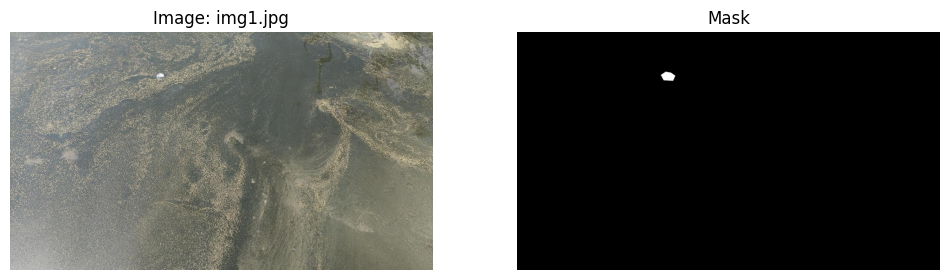

In [23]:
row = df.iloc[0]
image = cv2.imread(row["image_path"])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title(f"Image: {row['image_name']}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

## Data Splitting (70:15:15)

In [25]:
train_df, test_df = train_test_split(
    df,
    test_size=0.15,
    random_state=42,
    stratify=df["has_plastic"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["has_plastic"]
)

In [26]:
# reset
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 1445
Val  : 256
Test : 301


## Data Preprocessing

### Image Augmentation

In [29]:
IMAGE_HEIGHT = 448
IMAGE_WIDTH = 800

In [28]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

In [31]:
# transform only training and validation images

train_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

### Image Preprocessing (Class & Dataloader)

In [33]:
class Dataset(Dataset):
  def __init__(self, dataframe, transforms=None):
    self.dataframe = dataframe
    self.transforms = transforms

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    row = self.dataframe.iloc[idx]
    image = cv2.imread(row["image_path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.float32) # changes from 0/255 into 0.0/1.0 (0=background, 1=plastic)

    if self.transforms:
      transformed = self.transforms(image=image, mask=mask)
      image = transformed["image"]
      mask = transformed["mask"]

    mask = mask.unsqueeze(0) # add channel [1, H, W]

    return image, mask

In [34]:
train_dataset = Dataset(train_df, transforms=train_transform)
val_dataset = Dataset(val_df, transforms=val_transform)
test_dataset = Dataset(test_df, transforms=val_transform)

In [35]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

## Modelling

In [39]:
%%capture

model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

## Training

#### Training Hyperparameter

In [41]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEVICE

'cpu'

In [38]:
model = model.to(DEVICE)

#### Loss Function

##### Pos Weight Estimation for Class Imbalance Handlign

For Give more loss if positive pixel are predicted falsely (FP)

In [40]:
pos_pixels = 0
neg_pixels = 0

# step 1: sampling sebanyak 200
subset = train_df.sample(min(200, len(train_df)), random_state=42)

for _, row in subset.iterrows():
  mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
  mask = (mask > 127).astype(np.uint8)

  pos_pixels += mask.sum()
  neg_pixels += mask.size - mask.sum()

pos_weight = neg_pixels / max(pos_pixels, 1)

pos_weight

np.float64(17.441991871195814)

##### BCE

Loss function for Clasification per pixel

In [42]:
bce_loss = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight], device=DEVICE)
)

##### DICE

Loss function for Mask Overlapping

In [44]:
dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

#####  Combine

In [45]:
def combined_loss(pred_mask, true_mask, dice_weight=0.6, bce_weight=0.4):
  d_loss = dice_loss(pred_mask, true_mask)
  b_loss = bce_loss(pred_mask, true_mask)
  return dice_weight * d_loss + bce_weight * b_loss

#### Optimizer

In [48]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4 # ini anggep aja regularizationnya ges
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

/tmp/ipykernel_5418/2394790339.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


#### Metric

In [49]:
def apply_sigmoid(x):
  return torch.sigmoid(x)

In [50]:
def binarize_mask(prob_mask, threshold=0.5):
  return (prob_mask > threshold).float()

In [51]:
def compute_stats(preds, targets, eps=1e-7):
  preds = preds.float()
  targets = targets.float()

  tp = (preds * targets).sum(dim=(1,2,3))
  fp = (preds * (1 - targets)).sum(dim=(1,2,3))
  fn = ((1 - preds) * targets).sum(dim=(1,2,3))

  iou = (tp + eps) / (tp + fp + fn + eps)
  dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
  precision = (tp + eps) / (tp + fp + eps)
  recall = (tp + eps) / (tp + fn + eps)

  return {
      "iou": iou.mean().item(),
      "dice": dice.mean().item(),
      "precision": precision.mean().item(),
      "recall": recall.mean().item()
  }